In [1]:
#Single Agent environment 

from Single_ag_Environment import SingleSatelliteEnv
from gymnasium.utils.env_checker import check_env
import traceback
print(type(SingleSatelliteEnv))
# This will catch many common issues
env = SingleSatelliteEnv()
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print("Environment has issues:")
    traceback.print_exc()




<class 'type'>
Environment passes all checks!


/home/ethan/Documents/Research/Single_Agent_EO_Project/SingAgvenv/lib/python3.10/site-packages/gymnasium/utils/env_checker.py:434: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


In [2]:
#Baseline CGR
done=False
total_reward=0
while not done:
    

    # Choose an action manually
    action = 1

    # Take the action
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Observation: {obs}")
    done = terminated or truncated
    total_reward += reward

    print(f"Reward: {reward}, Done: {done}")

env.close()
print(f"Total reward: {total_reward}")

#Heuristic Baseline
#We implement adaptive sorting algorithm
done=False
total_reward=0
#Next used initial information to make decisions


#Next conduct step functions until end
while not done:
    

    # Choose an action manually
    action = 1

    # Take the action
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"Observation: {obs}")
    done = terminated or truncated
    total_reward += reward

    print(f"Reward: {reward}, Done: {done}")

env.close()
print(f"Total reward: {total_reward}")




Observation: {'contact plan': array([0.7, 0.1, 0.2, 0.2, 0.2, 0.8, 0.9, 0.3, 0.8, 0.9], dtype=float32), 'Remaining data': array([0.], dtype=float32), 'current timestep': array([2.], dtype=float32)}
Reward: [18.666668], Done: True
Total reward: [18.666668]
Observation: {'contact plan': array([0.7, 0.1, 0.2, 0.2, 0.2, 0.8, 0.9, 0.3, 0.8, 0.9], dtype=float32), 'Remaining data': array([0.], dtype=float32), 'current timestep': array([3.], dtype=float32)}
Reward: [1.7380954], Done: True
Total reward: [1.7380954]


/home/ethan/Documents/Research/Single_Agent_EO_Project/SingAgvenv/bin/python


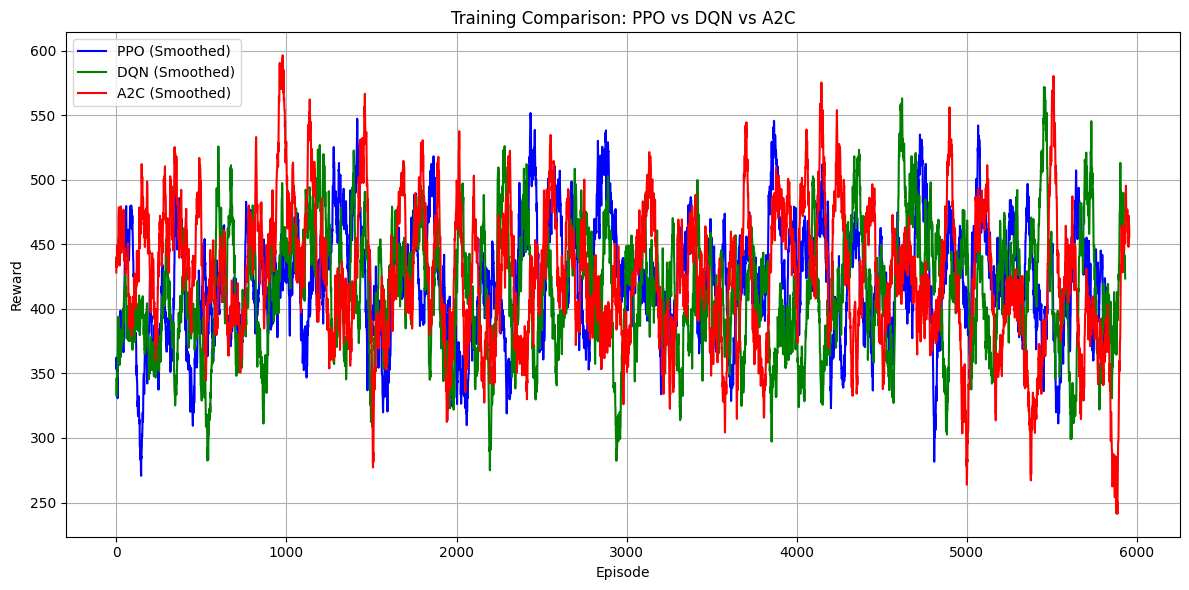

In [5]:
#Setup Stable Baseline3 Agents
import sys
import numpy as np
print(sys.executable)
import stable_baselines3
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []

    def _on_step(self) -> bool:
        # Check if episode info is available
        info = self.locals.get("infos", [{}])[0]
        if "episode" in info:
            reward = info["episode"]["r"]
            self.episode_rewards.append(reward)
        return True



def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')
def train_agent(agent_class, env_id, total_timesteps=50000):
    env = Monitor(SingleSatelliteEnv())
    model = agent_class("MultiInputPolicy", env, verbose=0)
    logger = RewardLogger()
    model.learn(total_timesteps=total_timesteps, callback=logger)
    return logger.episode_rewards


ppo_rewards = train_agent(PPO, env)
dqn_rewards = train_agent(DQN, env)
a2c_rewards = train_agent(A2C, env)


# Smoothed rewards
#smoothed_rewards = moving_average(rewards, window_size=50)

# Plotting
plt.figure(figsize=(12, 6))

# Raw (optional)
# plt.plot(ppo_rewards, label='PPO Raw', alpha=0.3)
# plt.plot(dqn_rewards, label='DQN Raw', alpha=0.3)
# plt.plot(a2c_rewards, label='A2C Raw', alpha=0.3)

# Smoothed
plt.plot(moving_average(ppo_rewards, 50), label='PPO (Smoothed)', color='blue')
plt.plot(moving_average(dqn_rewards, 50), label='DQN (Smoothed)', color='green')
plt.plot(moving_average(a2c_rewards, 50), label='A2C (Smoothed)', color='red')

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Comparison: PPO vs DQN vs A2C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
ppo_mean, ppo_std = evaluate_policy(model_ppo, eval_env, n_eval_episodes=10, render=False)

# Evaluate DQN
dqn_mean, dqn_std = evaluate_policy(model_dqn, eval_env, n_eval_episodes=10, render=False)

# Evaluate A2C
a2c_mean, a2c_std = evaluate_policy(model_a2c, eval_env, n_eval_episodes=10, render=False)

print(f"PPO Mean Reward: {ppo_mean:.2f} ± {ppo_std:.2f}")
print(f"DQN Mean Reward: {dqn_mean:.2f} ± {dqn_std:.2f}")
print(f"A2C Mean Reward: {a2c_mean:.2f} ± {a2c_std:.2f}")

NameError: name 'model_ppo' is not defined

In [5]:
obs, _ = env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated


In [6]:
#Need to make graphs and compare the different Stable baseline3 agents to the
#Heuristics


#Setup CleanRL Agents


In [7]:
#Evaluation Code
#Here we take results obtained from the different agents and we plot the reward curves
#And we evaluate the delivery ratio and the energy efficiency for the different results